In [1]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import (
    Any,
    List, 
    Union, 
    Optional, 
    Callable, 
    Sequence, 
    Literal
)
from transformers import (
    EsmForMaskedLM, 
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int

from plotly_utils import (
    imshow,
    line
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from interp_utils import get_hooked_state_dict, get_hooked_esm_config, get_logits_hooked_esm

In [3]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions
import tempfile
from dataclasses import dataclass

In [4]:
MODEL_PATH = "TheSatoLab-UTokyo/CoVFit"
FOLD_IDS_TO_USE = [0]
TARGET_FOLD_ID = 0
OUTPUT_PREFIX = "inference_results"
model_name = "facebook/esm2_t33_650M_UR50D"

device = "cuda"
CONTEXT_LEN = 1024
torch.autograd.grad_mode.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

# Model

In [5]:
def download_hf_checkpoints(repo_id, fold_ids):
    """
    Download specified fold checkpoint files from Hugging Face
    Hugging Faceから指定されたfoldのckptファイルをダウンロード
    
    Note: The model repository is public, so no token is required.
    注意：モデルリポジトリは公開されているため、トークンは不要です。
    """
    print(f"Downloading checkpoints from {repo_id} for folds: {fold_ids}")
    model_paths = []
    temp_dir = tempfile.mkdtemp()
    
    try:
        for fold_id in fold_ids:
            filename = f"covfit_model_20231102_{fold_id}.ckpt"
            print(f"Downloading {filename}...")
            
            # Download (no token needed for public repository)
            # ダウンロード（公開リポジトリのためトークン不要）
            downloaded_path = hf_hub_download(
                repo_id=repo_id,
                filename=filename,
                cache_dir=temp_dir
            )
            model_paths.append(downloaded_path)
            
        print(f"Successfully downloaded {len(model_paths)} checkpoint files")
        return model_paths, temp_dir
        
    except Exception as e:
        # Clean up temporary directory on failure
        # 失敗時はテンポラリディレクトリをクリーンアップ
        shutil.rmtree(temp_dir, ignore_errors=True)
        raise e

In [6]:
model_paths, temp_dir = download_hf_checkpoints(
    repo_id=MODEL_PATH,
    fold_ids=FOLD_IDS_TO_USE
)

task_dict_path = hf_hub_download(
    repo_id=MODEL_PATH,
    filename="task_id_dict.pt"
)

checkpoint = torch.load(model_paths[0], map_location=device)
final_weights = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint

original_task_id_infos = torch.load(task_dict_path, map_location=device)
n_targets_original = len(original_task_id_infos)

model_config = ModelConfig()
model_config.da_model_name = model_name

model = load_model_for_inference(model_paths[0], model_config, n_targets_original)
esm_fine_tuned = model.merge_and_unload() #merge PEFT adapter model with the base model and make a fully new model

# dumb thing to make hooked esm and this esm agree
esm_fine_tuned.esm.embeddings.token_dropout = False

# clean up after installing
if temp_dir and os.path.exists(temp_dir):
    shutil.rmtree(temp_dir, ignore_errors=True)
    print("Temporary files cleaned up")

covfit_model_20231102_0.ckpt:   0%|          | 0.00/2.64G [00:00<?, ?B/s]

Successfully downloaded 1 checkpoint files
Temporary files cleaned up


In [7]:
esm_fine_tuned = esm_fine_tuned.to(device)
esm_fine_tuned = esm_fine_tuned.eval()

In [8]:
esm_config = esm_fine_tuned.config
esm_config.token_dropout = False
esm_config.model_name = model_name

REPO_ID = esm_config.model_name
special_tokens_map_file = "special_tokens_map.json"
tokenizer_config = {}
tokenizer_config["vocab_file"] = hf_hub_download(repo_id=REPO_ID, filename="vocab.txt")
tokenizer_config["model_max_length"] = CONTEXT_LEN
with open(hf_hub_download(repo_id=REPO_ID, filename=special_tokens_map_file), "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [9]:
with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}

In [10]:
tokenizer = EsmTokenizer(**tokenizer_config)

hooked_esm_config = get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)
print(hooked_esm.load_state_dict(get_hooked_state_dict(esm_fine_tuned.state_dict(), hooked_esm_config)))

<All keys matched successfully>


In [11]:
# clean up memory
del model

# Data 

In [12]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [13]:
# data loading
with open("../../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [25]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
d_out_vocab = esm_fine_tuned.regressor[3].weight.size(0)
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [26]:
uniq_seqs = []
for suff in pathogen_suffixes:
    fasta_file = f"../../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    uniq_seqs_suff, unique_inds = np.unique(sequences, return_index=True) # For the purpose of eval, I only care about unique sequences 
    uniq_seqs.extend(uniq_seqs_suff)

In [28]:
# identical code to how it's compute_node_embeddings.py
cut_seqs = [get_protein_sequence(x, protein_coords) for x in uniq_seqs]
cut_seqs = list(np.unique([x for x in cut_seqs if len(x) > 3])) # remove any identical sequences again in case more appear after trimming

tok_output = tokenizer(cut_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)


print(pathogen_name)
print(f"Number unique sequences: {len(cut_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4382
torch.Size([4382, 1024])


In [29]:
# add padding mask to model
def add_perma_hooks_to_mask_pad_tokens(
    model: HookedTransformer, pad_token: int
) -> HookedTransformer:
    # Hook which operates on the tokens, and stores a mask where tokens equal [pad]
    def cache_padding_tokens_mask(tokens: Float[Tensor, "batch seq"], hook: HookPoint) -> None:
        hook.ctx["padding_tokens_mask"] = einops.rearrange(tokens == pad_token, "b sK -> b 1 1 sK")

    # Apply masking, by referencing the mask stored in the `hook_tokens` hook context
    def apply_padding_tokens_mask(
        attn_scores: Float[Tensor, "batch head seq_Q seq_K"],
        hook: HookPoint,
    ) -> None:
        attn_scores.masked_fill_(model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"], -1e5)
        if hook.layer() == model.cfg.n_layers - 1:
            del model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"]

    # Add these hooks as permanent hooks (i.e. they aren't removed after functions like run_with_hooks)
    for name, hook in model.hook_dict.items():
        if name == "hook_tokens":
            hook.add_perma_hook(cache_padding_tokens_mask)
        elif name.endswith("attn_scores"):
            hook.add_perma_hook(apply_padding_tokens_mask)

    return model


hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

In [30]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

In [31]:
def get_logit_hooked(output: Float[Tensor, "batch pos d_model"], tok_id):
    logits = get_logits_hooked_esm(output[:,0,:], esm_fine_tuned.regressor)[:,tok_id]
    torch.cuda.empty_cache()
    return logits

In [33]:
batch_len = 200
num_data = tok_seqs.size(0)
dim_mlp = esm_fine_tuned.regressor[0].weight.size(0)

# all output
output_logits = torch.zeros(num_data, d_out_vocab).to(device)

# data for SAE
sae_data_activations = torch.zeros(num_data, dim_mlp).to(device)

for i in tqdm(range(0,num_data,batch_len)):
    esm_output = hooked_esm(tok_seqs[i:i+batch_len])
    
    batch_output = get_logit_hooked(esm_output, list(range(d_out_vocab)))
    # apply linear and ReLU() of esm_regressor to get activations
    batch_activations = esm_fine_tuned.regressor[1](esm_fine_tuned.regressor[0](esm_output[:,0,:]))
    
    output_logits[i:i+batch_len] = batch_output
    sae_data_activations[i:i+batch_len] = batch_activations
    torch.cuda.empty_cache()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [04:27<00:00, 12.15s/it]


In [35]:
logit_id = original_task_id_infos["fitness_USA"]
# logit_id = original_task_id_infos["fitness_South Korea"]

In [36]:
topk = 40
high_fitness_dset_indices = output_logits[:,logit_id].topk(topk, largest=True).indices
low_fitness_dset_indices = output_logits[:,logit_id].topk(topk, largest=False).indices[list(range(topk-1,-1,-1))]

high_toks = tok_seqs[high_fitness_dset_indices, :]
low_toks = tok_seqs[low_fitness_dset_indices, :]
fitness_dset = torch.cat([low_toks, high_toks], dim=0)

In [37]:
high_logit_mean = get_logit_hooked(hooked_esm(high_toks), logit_id).mean().item()
low_logit_mean = get_logit_hooked(hooked_esm(low_toks), logit_id).mean().item()
print(high_logit_mean - low_logit_mean)
torch.cuda.empty_cache()

0.06459099054336548


In [38]:
# high_fitness_esm_out = hooked_esm(high_toks)
# torch.cuda.empty_cache()
# low_fitness_esm_out = hooked_esm(low_toks)
# torch.cuda.empty_cache()

# high_fitness_acts = esm_fine_tuned.regressor[1](esm_fine_tuned.regressor[0](high_fitness_esm_out)) 

# (Jump-ReLU) SAE
### SAE is used in dictionary learning -- Given our dataset $\{x_n\}_{n=1}^N$, we learn an encoder $f:X^m\to X^M$ and decoder $W = [d_1,... d_D]\, s.t.\, x_i\approx\sum_{j=1}^M f_j(x_i) * d_j$
### These $d_j$ represent features in our original space (of dimension $dim_{MLP}$) and by taking the dot product of these vectors with our $W_U[:,\text{logit\_id}]$, we can figure out which features the model believes are correlated with high and low fitness respectively. 
### Then, we can analyze the sequences in our dataset that have the largest activations for the coefficient of these features (Find the $x_i$ which causes $f_j(x_i)$ to have the largest values) and use that to figure out what these features can refer to
### Effectively, what this enables us to do is make a (somewhat justified) claim about what regressor MLP layer is doing when it's trying to predict fitness

In [46]:
# https://github.com/timaeus-research/devinterp/blob/main/src/devinterp/utils.py#L279
def cycle(iterable, limit=None):
    """
    Use this function to cycle through a dataloader. Unlike itertools.cycle, this function doesn't cache
    values in memory.

    Note: Be careful with cycling a shuffled interable. The shuffling will be different for each loop dependent on the seed
    state, unlike with itertools.cycle.

    :param iterable: Iterable to cycle through
    :param limit: Number of cycles to go through. If None, cycles indefinitely.
    """
    index = 0
    if limit is None:
        limit = float("inf")
    while True:
        for x in iterable:
            if index >= limit:
                return
            else:
                yield x
            index += 1

In [47]:
def linear_lr(step, steps):
    return 1 - (step / steps)


def constant_lr(*_):
    return 1.0

In [55]:
def rectangle(x: Tensor, width: float = 1.0) -> Tensor:
    """
    Returns the rectangle function value, i.e. K(x) = 1[|x| < width/2], as a float.
    """
    return (x.abs() < width / 2).float()


class Heaviside(torch.autograd.Function):
    """
    Implementation of the Heaviside step function, using straight through estimators for the derivative.

        forward:
            H(z,θ,ε) = 1[z > θ]

        backward:
            dH/dz := None
            dH/dθ := -1/ε * K(z/ε)

            where K is the rectangle kernel function with width 1, centered at 0: K(u) = 1[|u| < 1/2]
    """

    @staticmethod
    def forward(ctx: Any, z: Tensor, theta: Tensor, eps: float) -> Tensor:
        # Save any necessary information for backward pass
        ctx.save_for_backward(z, theta)
        ctx.eps = eps
        # Compute the output
        return (z > theta).float()

    @staticmethod
    def backward(ctx: Any, grad_output: Tensor) -> tuple[Tensor, Tensor, None]:
        # Retrieve saved tensors & values
        (z, theta) = ctx.saved_tensors
        eps = ctx.eps
        # Compute gradient of the loss with respect to z (no STE) and theta (using STE)
        grad_z = 0.0 * grad_output
        grad_theta = -(1.0 / eps) * rectangle((z - theta) / eps) * grad_output
        grad_theta_agg = grad_theta.sum(dim=0)  # note, sum over batch dim isn't strictly necessary

        return grad_z, grad_theta_agg, None

In [56]:
class JumpReLU(torch.autograd.Function):
    """
    Implementation of the JumpReLU function, using straight through estimators for the derivative.

        forward:
            J(z,θ,ε) = z * 1[z > θ]

        backward:
            dJ/dθ := -θ/ε * K((z - θ)/ε)
            dJ/dz := 1[z > θ]

            where K is the rectangle kernel function with width 1, centered at 0: K(u) = 1[|u| < 1/2]
    """

    @staticmethod
    def forward(ctx: Any, z: Tensor, theta: Tensor, eps: float) -> Tensor:
        # Save any necessary information for backward pass
        ctx.save_for_backward(z, theta)
        ctx.eps = eps
        # Compute the output
        return z * (z > theta).float()

    @staticmethod
    def backward(ctx: Any, grad_output: Tensor) -> tuple[Tensor, Tensor, None]:
        # Retrieve saved tensors & values
        (z, theta) = ctx.saved_tensors
        eps = ctx.eps
        # Compute gradient of the loss with respect to z (no STE) and theta (using STE)
        grad_z = (z > theta).float() * grad_output
        grad_theta = -(theta / eps) * rectangle((z - theta) / eps) * grad_output
        grad_theta_agg = grad_theta.sum(dim=0)  # note, sum over batch dim isn't strictly necessary
        return grad_z, grad_theta_agg, None



In [233]:
@dataclass
class ToySAEConfig:
    n_inst: int
    d_in: int
    d_sae: int
    sparsity_coeff: float = 0.2
    weight_normalize_eps: float = 1e-8
    tied_weights: bool = False
    ste_epsilon: float = 0.01

class ToySAE(nn.Module):
    W_enc: Float[Tensor, "inst d_in d_sae"]
    _W_dec: Float[Tensor, "inst d_sae d_in"] | None
    b_enc: Float[Tensor, "inst d_sae"]
    b_dec: Float[Tensor, "inst d_in"]

    # def __init__(self, cfg: ToySAEConfig, model: ToyModel) -> None:
    def __init__(self, cfg: ToySAEConfig, data) -> None:
        super(ToySAE, self).__init__()

        assert cfg.d_in == esm_fine_tuned.regressor[0].weight.size(0), "ToyModel's hidden dim doesn't match SAE input dim"
        # self.model = model.requires_grad_(False)
        # self.model.W.data[1:] = self.model.W.data[0]
        # self.model.b_final.data[1:] = self.model.b_final.data[0]
        self.n_inst = cfg.n_inst
        self.cfg = cfg
        self.data = cycle(data)


        self.W_enc = nn.Parameter(nn.init.kaiming_uniform_(
            torch.empty((cfg.n_inst, cfg.d_in, cfg.d_sae))
        ))
        self._W_dec = None if self.cfg.tied_weights else nn.Parameter(nn.init.kaiming_uniform_(t.empty((cfg.n_inst, cfg.d_sae, cfg.d_in))))

        self.b_enc = nn.Parameter(nn.init.kaiming_uniform_(
            torch.empty((cfg.n_inst, cfg.d_sae))
        ))
        self.b_dec = nn.Parameter(nn.init.kaiming_uniform_(
            torch.empty((cfg.n_inst, cfg.d_in))
        ))

        self.to(device)

    @property
    def W_dec(self) -> Float[Tensor, "inst d_sae d_in"]:
        return self._W_dec if self._W_dec is not None else self.W_enc.transpose(-1, -2)

    @property
    def W_dec_normalized(self) -> Float[Tensor, "inst d_sae d_in"]:
        """
        Returns decoder weights, normalized over the autoencoder input dimension.
        """
        # You'll fill this in later
        # return self.W_dec / (self.W_dec.norm(dim=-1, keepdim=True) + self.cfg.weight_normalize_eps)
        return self.W_dec / (torch.square(self.W_dec).sum(dim=-1, keepdim=True).sqrt() + self.cfg.weight_normalize_eps)

    def generate_batch(self) -> Float[Tensor, "batch inst d_in"]:
        """
        Generates a batch of hidden activations from our model.
        """
        return einops.repeat(next(self.data), "batch d_in -> batch inst d_in", inst=self.n_inst)


    def forward(
        self, h: Float[Tensor, "batch inst d_in"]
    ) -> tuple[
        dict[str, Float[Tensor, "batch inst"]],
        Float[Tensor, "batch inst"],
        Float[Tensor, "batch inst d_sae"],
        Float[Tensor, "batch inst d_in"],
    ]:
        """
        Forward pass on the autoencoder.

        Args:
            h: hidden layer activations of model

        Returns:
            loss_dict:       dict of different loss terms, each having shape (batch_size, n_inst)
            loss:            total loss (i.e. sum over terms of loss dict), same shape as loss terms
            acts_post:       autoencoder latent activations, after applying ReLU
            h_reconstructed: reconstructed autoencoder input
        """
        # You'll fill this in later

        acts_post = F.relu(einops.einsum(self.W_enc, (h - self.b_dec), "inst d_in d_sae, batch inst d_in -> batch inst d_sae") + self.b_enc)
        h_reconstructed = einops.einsum(self.W_dec_normalized, acts_post, "inst d_sae d_in, batch inst d_sae -> batch inst d_in") + self.b_dec

        l2_loss = torch.square(h-h_reconstructed).mean(dim=-1)
        l1_loss = torch.abs(acts_post).sum(dim=-1)

        return {"L_reconstruction":l2_loss, "L_sparsity":l1_loss}, (l2_loss + self.cfg.sparsity_coeff * l1_loss), acts_post, h_reconstructed


    def optimize(
        self,
        batch_size: int = 1024,
        steps: int = 10_000,
        log_freq: int = 100,
        lr: float = 1e-3,
        lr_scale: Callable[[int, int], float]=constant_lr,
        resample_method: Literal["simple", "advanced", None] = None,
        resample_freq: int = 2500,
        resample_window: int = 500,
        resample_scale: float = 0.5,
        hidden_sample_size: int = 256,
    ) -> list[dict[str, Any]]:
        """
        Optimizes the autoencoder using the given hyperparameters.

        Args:
            model:              we reconstruct features from model's hidden activations
            batch_size:         size of batches we pass through model & train autoencoder on
            steps:              number of optimization steps
            log_freq:           number of optimization steps between logging
            lr:                 learning rate
            lr_scale:           learning rate scaling function
            resample_method:    method for resampling dead latents
            resample_freq:      number of optimization steps between resampling dead latents
            resample_window:    number of steps needed for us to classify a neuron as dead
            resample_scale:     scale factor for resampled neurons
            hidden_sample_size: size of hidden value sample we add to the logs (for visualization)

        Returns:
            data_log:           dictionary containing data we'll use for visualization
        """
        assert resample_window <= resample_freq

        optimizer = torch.optim.Adam(self.parameters(), lr=lr)  # betas=(0.0, 0.999)
        frac_active_list = []
        progress_bar = tqdm(range(steps))

        # Create lists of dicts to store data we'll eventually be plotting
        data_log = []

        for step in progress_bar:
            # Resample dead latents
            if (resample_method is not None) and ((step + 1) % resample_freq == 0):
                frac_active_in_window = torch.stack(frac_active_list[-resample_window:], dim=0)
                if resample_method == "simple":
                    self.resample_simple(frac_active_in_window, resample_scale)
                elif resample_method == "advanced":
                    self.resample_advanced(frac_active_in_window, resample_scale, batch_size)

            # Update learning rate
            step_lr = lr * lr_scale(step, steps)
            for group in optimizer.param_groups:
                group["lr"] = step_lr

            # Get a batch of hidden activations from the model
            with torch.inference_mode():
                h = self.generate_batch()

            # Optimize
            loss_dict, loss, acts, _ = self.forward(h)
            torch.cuda.empty_cache()
            loss.mean(0).sum().backward()
            optimizer.step()
            optimizer.zero_grad()

            # Normalize decoder weights by modifying them directly (if not using tied weights)
            if not self.cfg.tied_weights:
                self.W_dec.data = self.W_dec_normalized.data

            # Calculate the mean sparsities over batch dim for each feature
            frac_active = (acts.abs() > 1e-8).float().mean(0)
            frac_active_list.append(frac_active)

            # Display progress bar, and log a bunch of values for creating plots / animations
            if step % log_freq == 0 or (step + 1 == steps):
                progress_bar.set_postfix(
                    lr=step_lr,
                    loss=loss.mean(0).sum().item(),
                    frac_active=frac_active.mean().item(),
                    **{k: v.mean(0).sum().item() for k, v in loss_dict.items()},  # type: ignore
                )
                with torch.inference_mode():
                    loss_dict, loss, acts, h_r = self.forward(
                        h := self.generate_batch()
                    )
                    torch.cuda.empty_cache()
                    
                data_log.append(
                    {
                        "steps": step,
                        "frac_active": (acts.abs() > 1e-8).float().mean(0).detach().cpu(),
                        "loss": loss.detach().cpu(),
                        "h": h.detach().cpu(),
                        "h_r": h_r.detach().cpu(),
                        **{name: param.detach().cpu() for name, param in self.named_parameters()},
                        **{name: loss_term.detach().cpu() for name, loss_term in loss_dict.items()},
                    }
                )
            
            torch.cuda.empty_cache()
        return data_log

    @torch.no_grad()
    def resample_simple(
        self,
        frac_active_in_window: Float[Tensor, "window inst d_sae"],
        resample_scale: float,
    ) -> None:
        """
        Resamples dead latents, by modifying the model's weights and biases inplace.

        Resampling method is:
            - For each dead neuron, generate a random vector of size (d_in,), and normalize these vecs
            - Set new values of W_dec and W_enc to be these normalized vecs, at each dead neuron
            - Set b_enc to be zero, at each dead neuron
        """

        dead_lats = (frac_active_in_window < 1e-8).all(dim=0) # inst d_sae
        n_dead = int(dead_lats.int().sum().item())

        v = torch.randn((n_dead, self.cfg.d_in), device=self.W_enc.device)
        v_normed = v / (v.norm(dim=-1, keepdim=True) + self.cfg.weight_normalize_eps)

        self.W_dec.data[dead_lats] = v_normed
        self.W_enc.data.transpose(-1,-2)[dead_lats] = (v_normed * resample_scale)
        self.b_enc.data[dead_lats] = 0

    @torch.no_grad()
    def resample_advanced(
        self,
        frac_active_in_window: Float[Tensor, "window inst d_sae"],
        resample_scale: float,
        batch_size: int,
    ) -> None:
        """
        Resamples latents that have been dead for `dead_feature_window` steps, according to `frac_active`.

        Resampling method is:
            - Compute the L2 reconstruction loss produced from the hidden state vecs `h`
            - Randomly choose values of `h` with probability proportional to their reconstruction loss
            - Set new values of W_dec & W_enc to be these centered & normalized vecs, at each dead neuron
            - Set b_enc to be zero, at each dead neuron
        """
        raise NotImplementedError()

In [290]:
THETA_INIT = 0.1


class JumpReLUToySAE(ToySAE):
    W_enc: Float[Tensor, "inst d_in d_sae"]
    _W_dec: Float[Tensor, "inst d_sae d_in"] | None
    b_enc: Float[Tensor, "inst d_sae"]
    b_dec: Float[Tensor, "inst d_in"]
    log_theta: Float[Tensor, "inst d_sae"]
    def __init__(self, cfg: ToySAEConfig, data, pre_set_bias=None):
        super(ToySAE, self).__init__()

        assert cfg.d_in == esm_fine_tuned.regressor[0].weight.size(0), "ToyModel's hidden dim doesn't match SAE input dim"
        # self.model = model.requires_grad_(False)
        # self.model.W.data[1:] = self.model.W.data[0]
        # self.model.b_final.data[1:] = self.model.b_final.data[0]

        self.n_inst = cfg.n_inst
        self.cfg = cfg
        self.data = cycle(data)

        self._W_dec = (
            None
            if self.cfg.tied_weights
            else nn.Parameter(nn.init.kaiming_uniform_(torch.empty((cfg.n_inst, cfg.d_sae, cfg.d_in))))
        )
        
        if pre_set_bias is not None:
            self.b_dec = torch.zeros(cfg.n_inst, cfg.d_in).to(device)
            self.b_enc = torch.zeros(cfg.n_inst, cfg.d_sae).to(device)
        else:
            self.b_dec = nn.Parameter(torch.zeros(cfg.n_inst, cfg.d_in))
            self.b_enc = nn.Parameter(torch.zeros(cfg.n_inst, cfg.d_sae))

        self.W_enc = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty((cfg.n_inst, cfg.d_in, cfg.d_sae)))
        )
        self.log_theta = nn.Parameter(torch.full((cfg.n_inst, cfg.d_sae), torch.log(torch.tensor(THETA_INIT))))

        self.to(device)

    @property
    def theta(self) -> Float[Tensor, "inst d_sae"]:
        return self.log_theta.exp()

    def forward(
        self, h: Float[Tensor, "batch inst d_in"]
    ) -> tuple[
        dict[str, Float[Tensor, "batch inst"]],
        Float[Tensor, ""],
        Float[Tensor, "batch inst d_sae"],
        Float[Tensor, "batch inst d_in"],
    ]:
        """
        Same as previous forward function, but allows for gated case as well (in which case we have different
        functional form, as well as a new term "L_aux" in the loss dict).
        """
        h_cent = h - self.b_dec
        
        acts_pre = (
            einops.einsum(
                h_cent, self.W_enc, "batch inst d_in, inst d_in d_sae -> batch inst d_sae"
            )
            + self.b_enc
        )
        # print(self.theta.mean(), self.theta.std(), self.theta.min(), self.theta.max())
        acts_relu = F.relu(acts_pre)
        acts_post = JumpReLU.apply(acts_relu, self.theta, self.cfg.ste_epsilon)

        h_reconstructed = (
            einops.einsum(
                acts_post, self.W_dec, "batch inst d_sae, inst d_sae d_in -> batch inst d_in"
            )
            + self.b_dec
        )

        loss_dict = {
            "L_reconstruction": (h_reconstructed - h).pow(2).mean(-1),
            "L_sparsity": Heaviside.apply(acts_relu, self.theta, self.cfg.ste_epsilon).sum(-1),
        }

        loss = loss_dict["L_reconstruction"] + self.cfg.sparsity_coeff * loss_dict["L_sparsity"]

        return loss_dict, loss, acts_post, h_reconstructed

    @torch.no_grad()
    def resample_simple(
        self,
        frac_active_in_window: Float[Tensor, "window inst d_sae"],
        resample_scale: float,
    ) -> None:
        dead_latents_mask = (frac_active_in_window < 1e-8).all(dim=0)  # [instances d_sae]
        n_dead = int(dead_latents_mask.int().sum().item())

        replacement_values = torch.randn((n_dead, self.cfg.d_in), device=self.W_enc.device)
        replacement_values_normed = replacement_values / (
            replacement_values.norm(dim=-1, keepdim=True) + self.cfg.weight_normalize_eps
        )

        # New names for weights & biases to resample
        self.W_enc.data.transpose(-1, -2)[dead_latents_mask] = (
            resample_scale * replacement_values_normed
        )
        self.W_dec.data[dead_latents_mask] = replacement_values_normed
        self.b_enc.data[dead_latents_mask] = 0.0
        self.log_theta.data[dead_latents_mask] = torch.log(torch.tensor(THETA_INIT))

    @torch.no_grad()
    def resample_advanced(
        self,
        frac_active_in_window: Float[Tensor, "window inst d_sae"],
        resample_scale: float,
        batch_size: int,
    ) -> None:
        h = self.generate_batch()
        l2_loss = self.forward(h)[0]["L_reconstruction"]

        for instance in range(self.cfg.n_inst):
            is_dead = (frac_active_in_window[:, instance] < 1e-8).all(dim=0)
            dead_latents = torch.nonzero(is_dead).squeeze(-1)
            n_dead = dead_latents.numel()
            if n_dead == 0:
                continue

            l2_loss_instance = l2_loss[:, instance]  # [batch_size]
            if l2_loss_instance.max() < 1e-6:
                continue

            distn = Categorical(probs=l2_loss_instance.pow(2) / l2_loss_instance.pow(2).sum())
            replacement_indices = distn.sample((n_dead,))  # type: ignore

            replacement_values = (h - self.b_dec)[replacement_indices, instance]  # [n_dead d_in]
            replacement_values_normalized = replacement_values / (
                replacement_values.norm(dim=-1, keepdim=True) + self.cfg.weight_normalize_eps
            )

            W_enc_norm_alive_mean = (
                self.W_enc[instance, :, ~is_dead].norm(dim=0).mean().item()
                if (~is_dead).any()
                else 1.0
            )

            # New names for weights & biases to resample
            self.b_enc.data[instance, dead_latents] = 0.0
            self.log_theta.data[instance, dead_latents] = torch.log(torch.tensor(THETA_INIT))
            self.W_dec.data[instance, dead_latents, :] = replacement_values_normalized
            self.W_enc.data[instance, :, dead_latents] = (
                replacement_values_normalized.T * W_enc_norm_alive_mean * resample_scale
            )

In [291]:
torch.autograd.grad_mode.set_grad_enabled(True)

torch.autograd.grad_mode.set_grad_enabled(mode=True)

## Training SAE (multiplying dataset by constant so that bias does not take over)

In [343]:
MAGNIFICATION_SIZE = 1e3

In [394]:
d_in = sae_data_activations.size(1)
d_sae = d_in * 16
sae_train_dataset = torch.utils.data.DataLoader(sae_data_activations * MAGNIFICATION_SIZE, batch_size=200, shuffle=False)
# print(d_sae)
# print(d_in)
# print(sae_data_activations.shape)

In [395]:
jumprelu_sae = JumpReLUToySAE(
    cfg=ToySAEConfig(
        n_inst=1, # used to train multiple models at once -- unnecessary at this time, so n_inst=1
        d_in=d_in, 
        d_sae=d_sae, 
        tied_weights=True, 
        sparsity_coeff=0.1,
    ),
    data=sae_train_dataset,
    # pre_set_bias=sae_data_activations.mean(dim=0)
    pre_set_bias=None
)

In [396]:
jumprelu_data_log = jumprelu_sae.optimize(
    steps=500,
    resample_method="advanced",
)  # batch_size=4096?

100%|███████████████████| 500/500 [00:02<00:00, 218.64it/s, L_reconstruction=276, L_sparsity=623, frac_active=0.152, loss=338, lr=0.001]


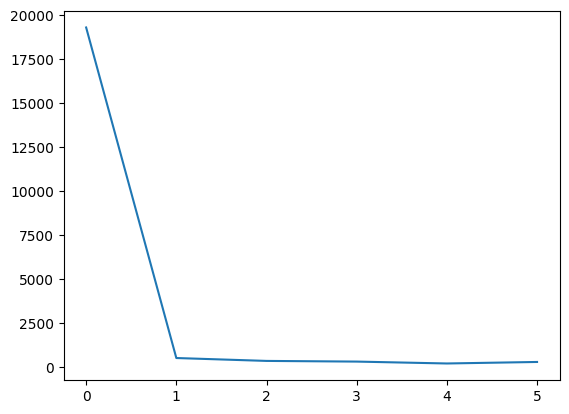

In [397]:
plt.plot(list(range(len(jumprelu_data_log))), [d["loss"].mean(dim=0) for d in jumprelu_data_log])
plt.show()

# Visualizing features scores ($d_j$ dot product with $W_U[:,\text{logit\_id}]$ for each j)
### What you'll see is that most features are not correlated with fitness at all but there are a few key features that have high(-er) cosine score with the fitness decoding column

In [398]:
logit_id_decoding_row = esm_fine_tuned.regressor[3].weight[logit_id,:]
sae_feature_scores = einops.einsum(jumprelu_sae.W_dec[0], logit_id_decoding_row, "d_sae d_mlp, d_mlp -> d_sae").detach().cpu().numpy()

In [399]:
sae_feature_score_sorted_indices = np.argsort(sae_feature_scores)[::-1]
sae_quantile_95 = np.quantile(sae_feature_scores, 0.99)
sae_quantile_05 = np.quantile(sae_feature_scores, 0.01)
high_fit_sae_feats = sae_feature_score_sorted_indices[np.argwhere(sae_feature_scores[sae_feature_score_sorted_indices] > sae_quantile_95)[:,0]]
low_fit_sae_feats = sae_feature_score_sorted_indices[np.argwhere(sae_feature_scores[sae_feature_score_sorted_indices] < sae_quantile_05)[:,0]]

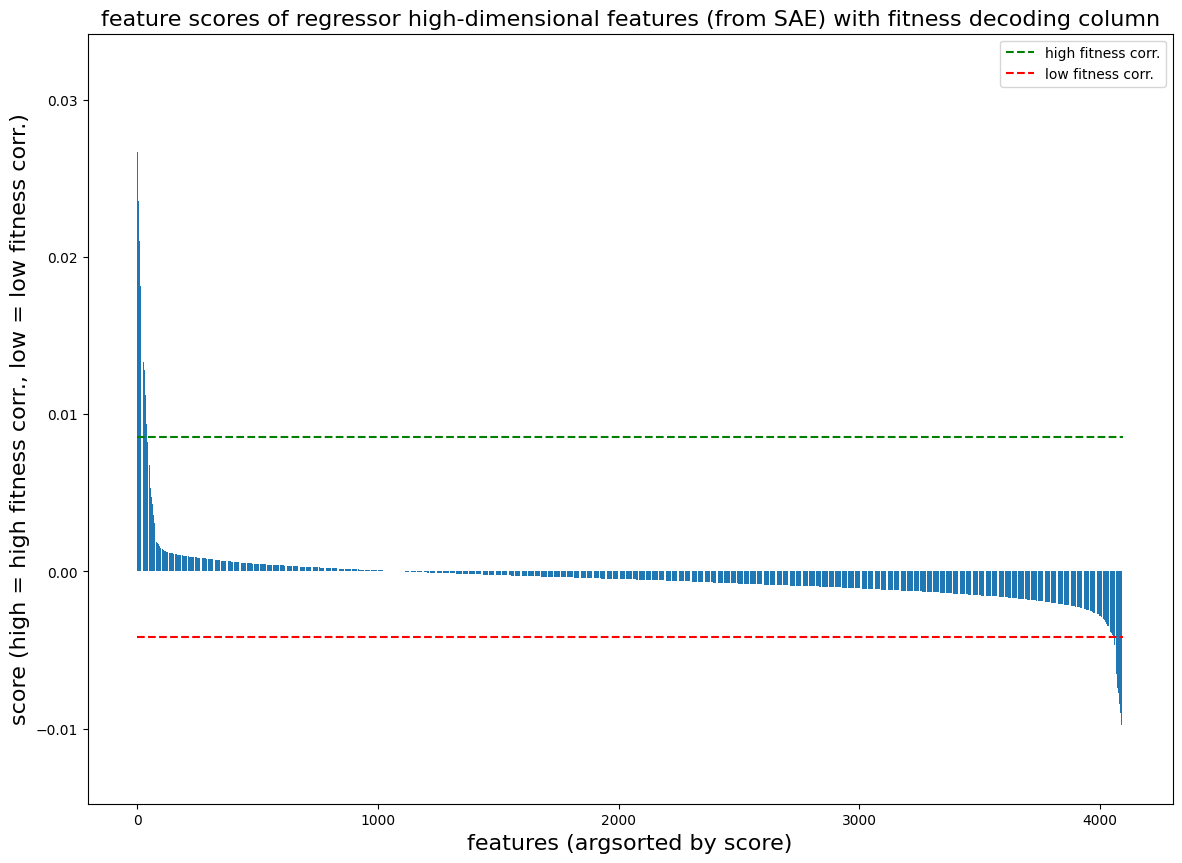

In [400]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.set_title("feature scores of regressor high-dimensional features (from SAE) with fitness decoding column", fontsize=16)
ax.bar(list(range(d_sae)), sae_feature_scores[sae_feature_score_sorted_indices])
ax.plot([0,d_sae], [sae_quantile_95, sae_quantile_95], color="green", label="high fitness corr.", linestyle="dashed")
ax.plot([0,d_sae], [sae_quantile_05, sae_quantile_05], color="red", label="low fitness corr.", linestyle="dashed")
ax.legend()

ax.set_xlabel("features (argsorted by score)", fontsize=16)
ax.set_ylabel("score (high = high fitness corr., low = low fitness corr.)", fontsize=16)
plt.show()

# Visualizing key features correlated with fitness (features with top 1% and bottom 1% cosine similarity with fitness decoding column respectively)

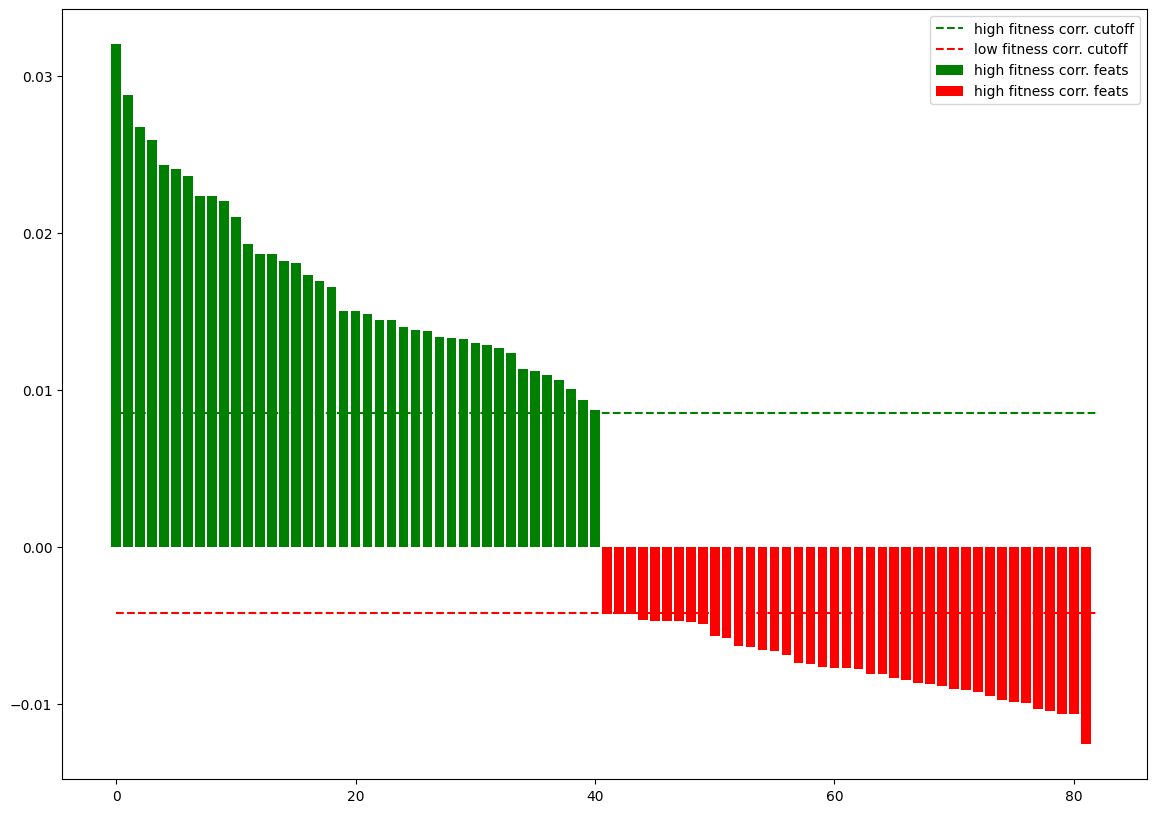

In [401]:
num_feats = high_fit_sae_feats.shape[0]+low_fit_sae_feats.shape[0]
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.bar(list(range(high_fit_sae_feats.shape[0])), sae_feature_scores[high_fit_sae_feats], color="green", label="high fitness corr. feats")
ax.bar(list(range(high_fit_sae_feats.shape[0], num_feats)), sae_feature_scores[low_fit_sae_feats], color="red", label="high fitness corr. feats")
ax.plot([0,num_feats], [sae_quantile_95, sae_quantile_95], color="green", label="high fitness corr. cutoff", linestyle="dashed")
ax.plot([0,num_feats], [sae_quantile_05, sae_quantile_05], color="red", label="low fitness corr. cutoff", linestyle="dashed")
ax.legend()
plt.show()

# Examining coefficients $f_j(x_i)$ of each argsorted features $d_j$ shown above

### Ideally, the coefficients $f_j(x_i^{\text{HIGH fit}})$ of the high-fitness seq. should be large on the features corr. w/ high fitness. Similarly, the coefficients $f_j(x_i^{\text{LOW fit}})$ of the low-fitness seq. should be large on the features corr. w/ low fitness (this is the 2nd row)
### Further, the high-fitness coefficients should NOT be active on the low-fit features and vice versa (this is the 3rd row)

In [402]:
high_fitness_acts = sae_data_activations[high_fitness_dset_indices, :]
low_fitness_acts = sae_data_activations[low_fitness_dset_indices, :]

In [425]:
print(mean_low_fit_sae_coefs[sae_feature_score_sorted_indices[0]])

0.58884615


In [403]:
_, _, high_fitness_sae_coefs, high_fit_recon = jumprelu_sae.forward(high_fitness_acts[:, None, :] * MAGNIFICATION_SIZE) #[batch, 1, d_sae], 1 for the n_inst which will be removed
_, _, low_fitness_sae_coefs, low_fit_recon = jumprelu_sae.forward(low_fitness_acts[:, None, :] * MAGNIFICATION_SIZE) #[batch, 1, d_sae], 1 for the n_inst which will be removed

mean_high_fit_sae_coefs = high_fitness_sae_coefs.mean(dim=0)[0].detach().cpu().numpy() / MAGNIFICATION_SIZE
mean_low_fit_sae_coefs = low_fitness_sae_coefs.mean(dim=0)[0].detach().cpu().numpy() / MAGNIFICATION_SIZE

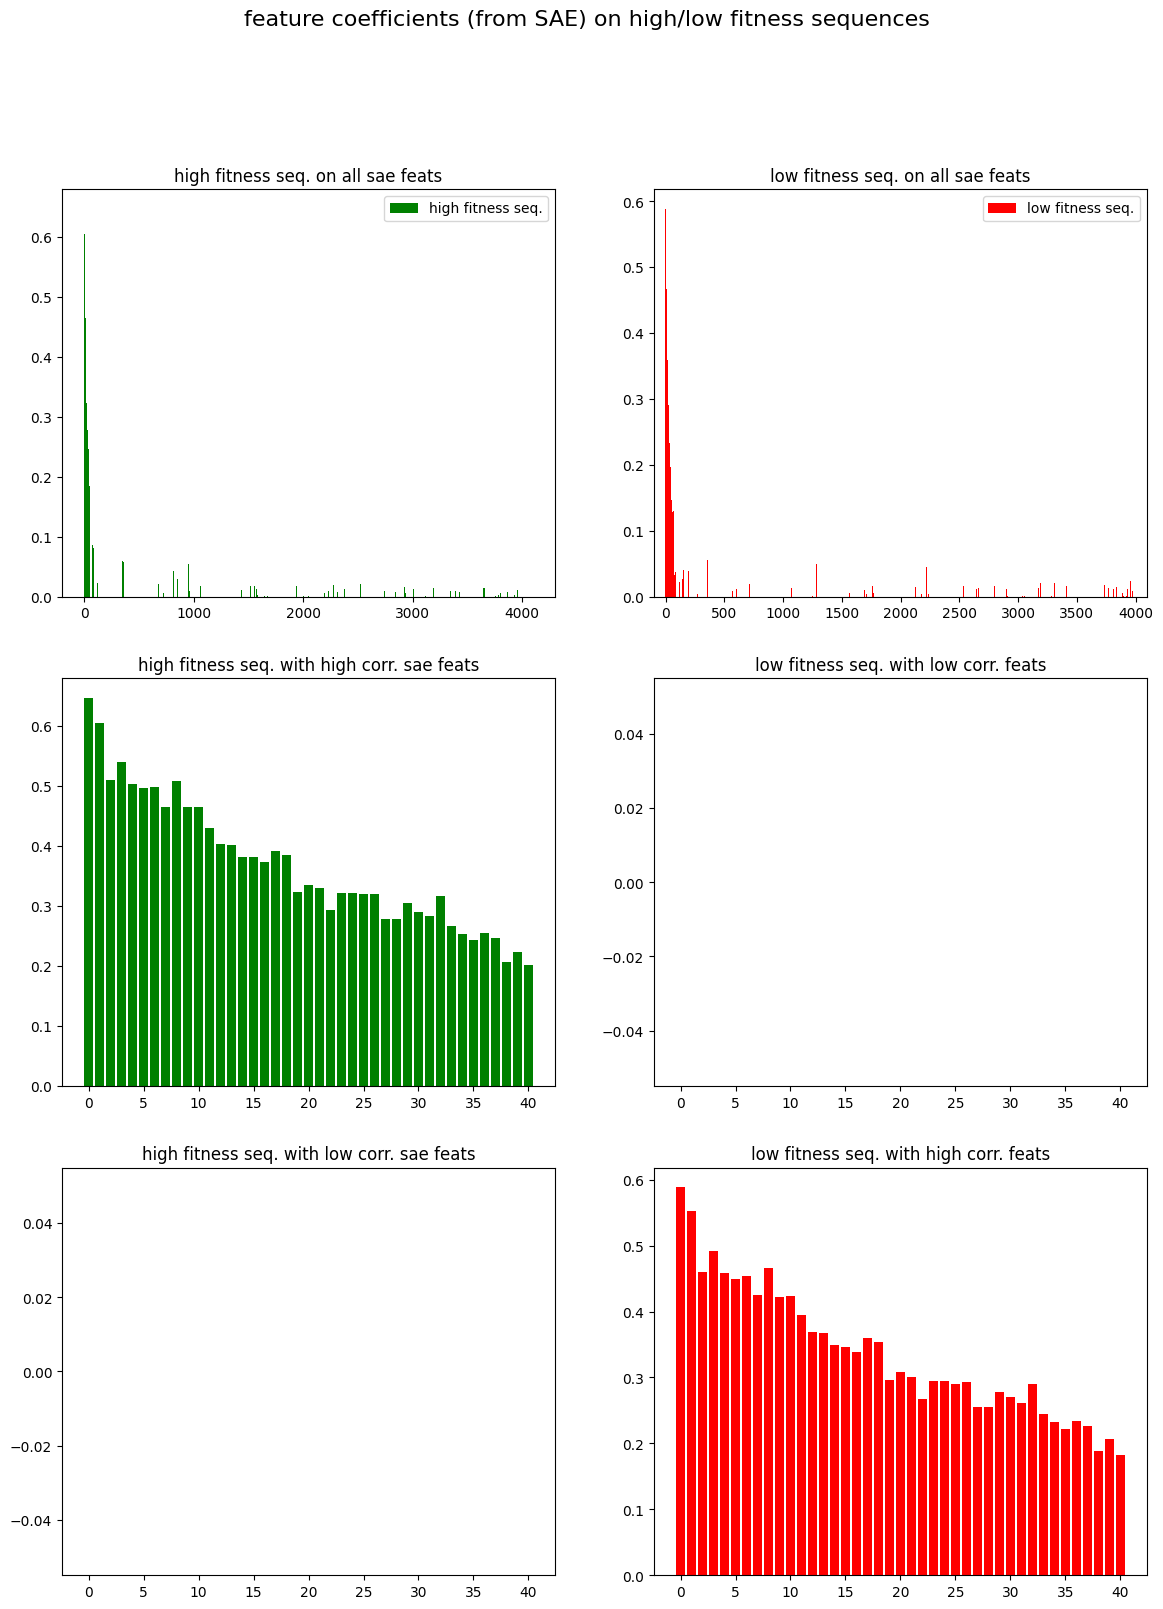

In [431]:
fig, ax = plt.subplots(3,2,figsize=(14,18))
fig.suptitle("feature coefficients (from SAE) on high/low fitness sequences", fontsize=16)
ax[0,0].bar(list(range(d_sae)), mean_high_fit_sae_coefs[sae_feature_score_sorted_indices], color="green", label="high fitness seq.")
ax[0,1].bar(list(range(d_sae)), mean_low_fit_sae_coefs[sae_feature_score_sorted_indices], color="red", label="low fitness seq.")
ax[0,1].set_xlim([-100, d_sae])

ax[1,0].bar(list(range(high_fit_sae_feats.shape[0])), mean_high_fit_sae_coefs[high_fit_sae_feats], color="green", label="high fitness seq.")
ax[1,1].bar(list(range(low_fit_sae_feats.shape[0])), mean_low_fit_sae_coefs[low_fit_sae_feats], color="red", label="low fitness seq.")


ax[2,0].bar(list(range(low_fit_sae_feats.shape[0])), mean_high_fit_sae_coefs[low_fit_sae_feats], color="green", label="high fitness seq.")
ax[2,1].bar(list(range(high_fit_sae_feats.shape[0])), mean_low_fit_sae_coefs[high_fit_sae_feats], color="red", label="low fitness seq.")



ax[0,0].legend()
ax[0,0].set_title("high fitness seq. on all sae feats")

ax[0,1].legend()
ax[0,1].set_title("low fitness seq. on all sae feats")

ax[1,0].set_title("high fitness seq. with high corr. sae feats")

ax[1,1].set_title("low fitness seq. with low corr. feats")

ax[2,0].set_title("high fitness seq. with low corr. sae feats")

ax[2,1].set_title("low fitness seq. with high corr. feats")

plt.show()